# CliffordClock known-answer validation (KA1-4)

This notebook walks the four known-answer validation cases
(`docs/validation.md`, `tests/test_known_answers.py`): the moment a
metrology-lab reviewer needs, where the tool reproduces numbers **the
community already knows**. `notebooks/01_end_to_end_demo.ipynb` checks
the tool against its own closed forms; these four cases check it
against literature-cited polarizabilities and textbook formulas the
community already uses.

For each case: what field/state, what the textbook (or an independent
hand calculation) predicts, and what `cliffordclock.pipeline.run_pipeline_full`
returns, at a genuine (not femtosecond-toy) interrogation time, via the
physical E14b DC-Stark coupling (`coupling.type: stark_dc`,
`docs/coupling.md`) and the fast-path architecture (`docs/timescales.md`).

**Status: pre-validation research code.** See the top-level README and
`docs/validation.md` for the full validation status; this notebook covers
only KA1-4 (`benchmarks/` adds a published-dataset comparison next).

In [1]:
%matplotlib inline
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# tests/ is not a package on the default path; add it explicitly so this
# notebook can reuse tests/reference_impl.py's independent KA3 hand
# calculation (the same import tests/test_known_answers.py relies on
# pytest's rootdir-insertion for).
sys.path.insert(0, str(Path.cwd().parent / "tests"))
import reference_impl
from cliffordclock.constants import BOLTZMANN_K, PLANCK_H, SPEED_OF_LIGHT
from cliffordclock.ensemble.species import get_species
from cliffordclock.pipeline import PipelineConfig, run_pipeline_full

## KA1/KA2: uniform-field DC-Stark shift (Sr87, Yb171)

CONVENTIONS.md E14b: `Delta_nu/nu0 = -(Delta_alpha/2)|E|^2/(h nu0)`, the
textbook DC-Stark formula every optical-lattice-clock paper in this space
states directly. `Delta_alpha` comes from the species registry's
cited literature value (Middelmann et al. 2012 for Sr87, Sherman et al.
2012 for Yb171); `coupling.type: stark_dc` resolves it with no override.

A single static lattice node (`n_quad=1`) is used: a *uniform* field gives
every quadrature node an identical shift by construction, which would hit
a latent zero-variance edge case in the T2\* calculation for a wider
quadrature. That edge case is a pre-existing pipeline issue found during
this WP and tracked in `docs/validation.md`; this notebook's single-node
setup does not trigger it.


In [2]:
def ka1_ka2_config(species_name: str, field_v_per_m: float) -> PipelineConfig:
    return PipelineConfig.from_dict(
        {
            "species": species_name,
            "trap": {"omega_xyz": [2.0e5, 2.0e5, 2.0e5]},
            "field": {
                "synthetic": {"kind": "uniform", "params": {"e0": [0.0, 0.0, field_v_per_m]}}
            },
            "coupling": {"type": "stark_dc"},
            "ensemble": {
                "regime": "lattice",
                "temperature_uK": 1.0,
                "motional_n": [0, 0, 0],
                "n_quad": 1,
            },
            "integration": {"time_s": 1.0},  # a genuine 1 s interrogation (E29 fast path)
        }
    )


def textbook_dc_stark_shift(species_name: str, field_v_per_m: float) -> float:
    species = get_species(species_name)
    return (
        -(species.delta_alpha_dc_si / 2.0)
        * field_v_per_m**2
        / (PLANCK_H * species.clock_frequency_hz)
    )


FIELD_V_PER_M = 100.0  # a lab-typical stray DC field

ka_results = {}
for species_name in ("Sr87", "Yb171"):
    config = ka1_ka2_config(species_name, FIELD_V_PER_M)
    result = run_pipeline_full(config)
    expected = textbook_dc_stark_shift(species_name, FIELD_V_PER_M)
    ka_results[species_name] = (expected, result.report.mean_fractional_shift)
    species = get_species(species_name)
    print(f"{species_name} @ {FIELD_V_PER_M:.0f} V/m, T=1s:")
    print(f"  textbook Delta_nu/nu0 = {expected:+.6e}")
    print(f"  engine    Delta_nu/nu0 = {result.report.mean_fractional_shift:+.6e}")
    print(f"  Delta_nu               = {expected * species.clock_frequency_hz:+.6e} Hz")
    rel_err = abs(result.report.mean_fractional_shift - expected) / abs(expected)
    print(f"  relative error = {rel_err:.3e}")
    print()

Sr87 @ 100 V/m, T=1s:
  textbook Delta_nu/nu0 = -7.170524e-17
  engine    Delta_nu/nu0 = -7.170524e-17
  Delta_nu               = -3.077790e-02 Hz
  relative error = 0.000e+00

Yb171 @ 100 V/m, T=1s:
  textbook Delta_nu/nu0 = -3.498114e-17
  engine    Delta_nu/nu0 = -3.498114e-17
  Delta_nu               = -1.813058e-02 Hz
  relative error = 0.000e+00



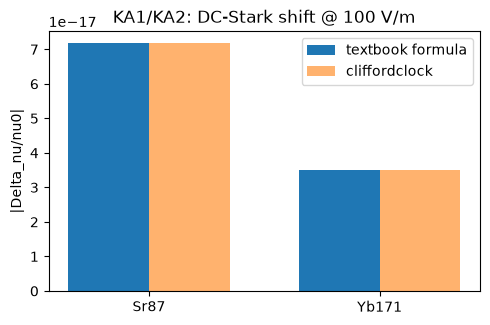

In [3]:
species_names = list(ka_results)
textbook_vals = [abs(ka_results[s][0]) for s in species_names]
engine_vals = [abs(ka_results[s][1]) for s in species_names]

fig, ax = plt.subplots(figsize=(5, 3.5))
x = np.arange(len(species_names))
width = 0.35
ax.bar(x - width / 2, textbook_vals, width, label="textbook formula")
ax.bar(x + width / 2, engine_vals, width, label="cliffordclock", alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(species_names)
ax.set_ylabel("|Delta_nu/nu0|")
ax.set_title(f"KA1/KA2: DC-Stark shift @ {FIELD_V_PER_M:.0f} V/m")
ax.legend()
fig.tight_layout()
plt.show()

## KA3: gradient line shift + broadening (Yb171)

A field linear in position makes the E14b pivot a *quadratic* polynomial
in position; over a ground-motional-state lattice ensemble (an exact
Gaussian position density), both the mean shift and its variance are known
in closed form via Gaussian-moment perturbation theory
(`reference_impl.stark_shift_mean_and_variance`, independent plain NumPy;
see its derivation comment in `tests/reference_impl.py`).


In [4]:
KA3_E0 = np.array([30.0, -20.0, 10.0])  # V/m
KA3_GRAD = np.array(  # V/m^2, grad[i, j] = d_i E_j (E13)
    [[5.0e2, -2.0e2, 0.0], [1.0e2, 3.0e2, -1.0e2], [0.0, 2.0e2, -6.0e2]]
)
KA3_OMEGA = np.array([2.0e5, 2.0e5, 2.0e5])
KA3_N_QUAD = 6

config = PipelineConfig.from_dict(
    {
        "species": "Yb171",
        "trap": {"omega_xyz": KA3_OMEGA.tolist()},
        "field": {
            "synthetic": {
                "kind": "constant_gradient",
                "params": {"e0": KA3_E0.tolist(), "grad": KA3_GRAD.tolist()},
            }
        },
        "coupling": {"type": "stark_dc"},
        "ensemble": {
            "regime": "lattice",
            "temperature_uK": 1.0,
            "motional_n": [0, 0, 0],
            "n_quad": KA3_N_QUAD,
        },
        "integration": {"time_s": 1.0},
    }
)
result = run_pipeline_full(config)

species = get_species("Yb171")
k_s = species.resolve_stark_coefficient_hz_per_v2_m2()
expected_mean, expected_var = reference_impl.stark_shift_mean_and_variance(
    KA3_E0, KA3_GRAD, KA3_OMEGA, species.mass_kg, k_s, species.clock_frequency_hz
)

shift = np.asarray(result.ensemble_result.fractional_shift)
weights = np.asarray(result.weights)
weights = weights / np.sum(weights)
pipeline_mean = float(np.sum(weights * shift))
pipeline_var = float(np.sum(weights * (shift - pipeline_mean) ** 2))

print(f"reference <Delta_nu/nu0>_psi = {expected_mean:+.6e}")
print(f"engine    <Delta_nu/nu0>_psi = {pipeline_mean:+.6e}")
print(f"reference sqrt(Var)_psi      = {math.sqrt(expected_var):.6e}")
print(f"engine    sqrt(Var)_psi      = {math.sqrt(pipeline_var):.6e}")
print(f"mean relative error: {abs(pipeline_mean - expected_mean) / abs(expected_mean):.3e}")
print(f"var  relative error: {abs(pipeline_var - expected_var) / abs(expected_var):.3e}")

reference <Delta_nu/nu0>_psi = -4.897360e-18
engine    <Delta_nu/nu0>_psi = -4.897360e-18
reference sqrt(Var)_psi      = 4.656821e-24
engine    sqrt(Var)_psi      = 4.656821e-24
mean relative error: 0.000e+00
var  relative error: 5.452e-11


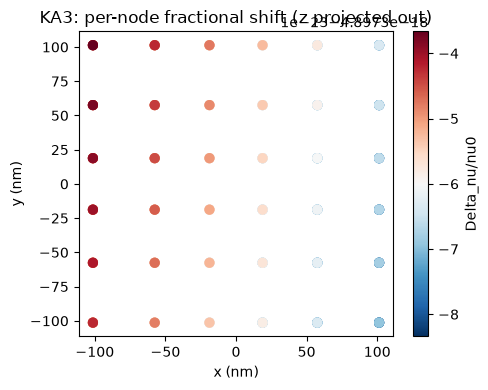

In [5]:
nodes = np.asarray(result.trajectories)
fig, ax = plt.subplots(figsize=(5, 4))
sc = ax.scatter(nodes[:, 0] * 1e9, nodes[:, 1] * 1e9, c=shift, cmap="RdBu_r", s=40)
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
ax.set_title("KA3: per-node fractional shift (z projected out)")
fig.colorbar(sc, ax=ax, label="Delta_nu/nu0")
fig.tight_layout()
plt.show()

## KA4: second-order Doppler shift (Sr87)

A classical thermal ensemble in a harmonic trap, `integration.mode:
secular` (E30, the orbit-time-averaged `delta_omega~`, carrying the full
kinematic term), and a *zero* field (`e0 = [0, 0, 0]`) so the E14b Stark
contribution is identically zero for any species, isolating the
kinematic (second-order Doppler) term. Equipartition (see
`tests/test_known_answers.py`'s KA4 docstring for the per-axis derivation,
including why the orbit-time-average converges to the same value as the
naive instantaneous formula): `<Delta_nu/nu0> = -<v^2>/2c^2 =
-3 k_B T / (2 m c^2)`.


In [6]:
species = get_species("Sr87")
temperature_u_k = 5.0
temperature_k = temperature_u_k * 1.0e-6
expected = -3.0 * BOLTZMANN_K * temperature_k / (2.0 * species.mass_kg * SPEED_OF_LIGHT**2)

config = PipelineConfig.from_dict(
    {
        "species": "Sr87",
        "trap": {"omega_xyz": [2.0e5, 2.0e5, 2.0e5]},
        "field": {"synthetic": {"kind": "uniform", "params": {"e0": [0.0, 0.0, 0.0]}}},
        "coupling": {"type": "stark_dc"},
        "ensemble": {
            "regime": "classical",
            "temperature_uK": temperature_u_k,
            "size": 5000,
            "seed": 42,
        },
        "integration": {"mode": "secular", "time_s": 1.0},
    }
)
result = run_pipeline_full(config)

measured = result.report.mean_fractional_shift
sem = result.report.shift_std_error
print(f"equipartition prediction: {expected:+.6e}")
print(f"engine measured (M=5000): {measured:+.6e} +/- {sem:.2e} (SEM)")
print(f"deviation: {abs(measured - expected) / sem:.3f} SEM")

equipartition prediction: -7.983437e-21
engine measured (M=5000): -8.003764e-21 +/- 6.33e-23 (SEM)
deviation: 0.321 SEM


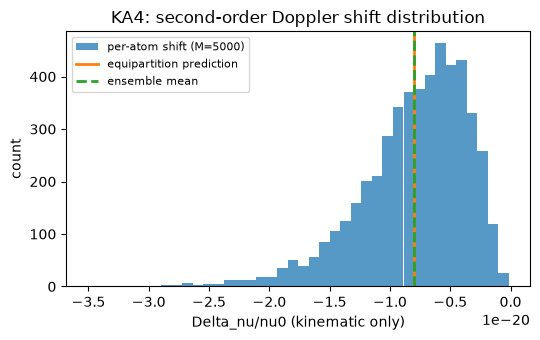

In [7]:
per_atom_shift = np.asarray(result.ensemble_result.fractional_shift)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(per_atom_shift, bins=40, alpha=0.75, label="per-atom shift (M=5000)")
ax.axvline(expected, color="C1", linewidth=2, label="equipartition prediction")
ax.axvline(measured, color="C2", linestyle="--", linewidth=2, label="ensemble mean")
ax.set_xlabel("Delta_nu/nu0 (kinematic only)")
ax.set_ylabel("count")
ax.set_title("KA4: second-order Doppler shift distribution")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Where to go next

- `docs/validation.md`: the full validation table (V1-V4 self-consistency
  checks + this notebook's KA1-4), with measured agreement for every case.
- `docs/coupling.md`: the E14b physical DC-Stark coupling in full
  (species registry, precision discipline, the pipeline wiring this
  notebook exercises).
- `docs/CONVENTIONS.md`: every equation cited above, with units.
- `tests/test_known_answers.py`: the pytest versions of every case
  above (run in CI on every push).

**Next:** `benchmarks/` compares the tool against a published NIST/JILA
experimental dataset: the step from "reproduces the right equations"
(this notebook) to "matches a real measurement."